In [49]:
from pathlib import Path

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'data' / 'raw').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'diabetes.csv'
MODELS_DIR = PROJECT_ROOT / 'models'

PROJECT_ROOT = Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'diabetes.csv'
MODELS_DIR = PROJECT_ROOT / 'models'

In [50]:
def merge_csvs_and_remove_duplicates(files):
    df_list = []
    for file in files:
        df_list.append(pd.read_csv(file))
    df = pd.concat(df_list, ignore_index=True)
    df = df.drop_duplicates(subset=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'], keep='first')
    df = df.sort_values(by=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'], ascending=[True, True, True, True, True, True, True, True, True])
    df.drop_duplicates(inplace=True)
    return df

files = [RAW_DATA_DIR / f'diabetes ({number}).csv' for number in range(1, 9)]
df = merge_csvs_and_remove_duplicates(files)
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED_DATA_PATH, index=False)


Форма датасета: (778, 9)

Типы данных:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Пропуски:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Первые строки:
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
537            0       57             60              0        0  21.7   
596            0       67             76              0        0  45.3   
589            0       73              0              0        0  21.1   
466            0 

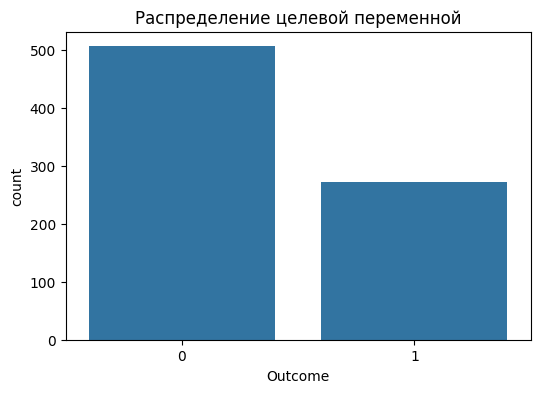

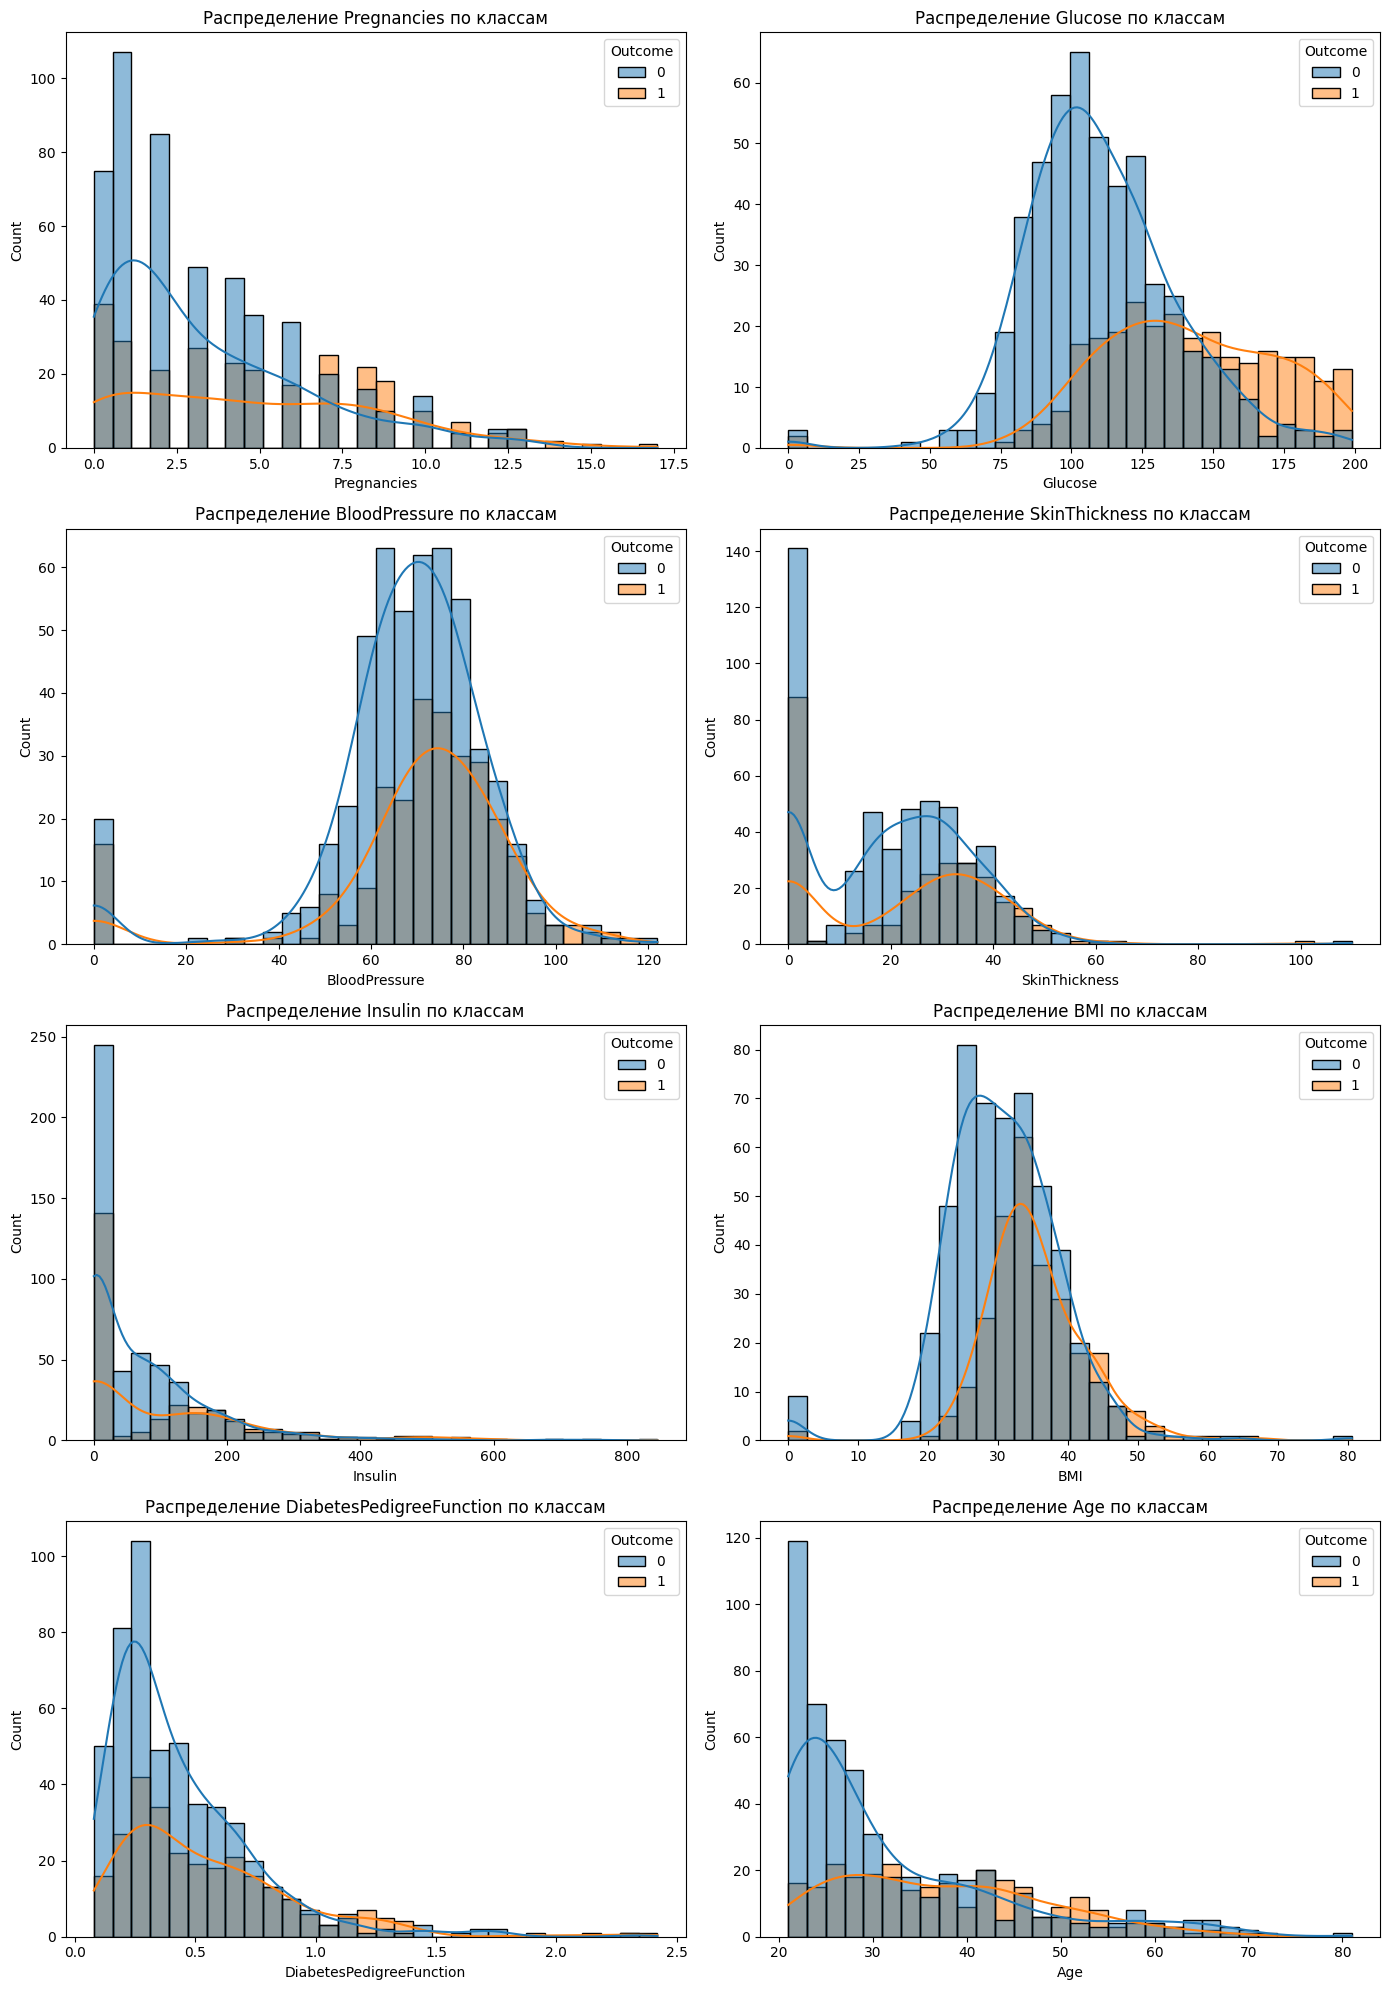

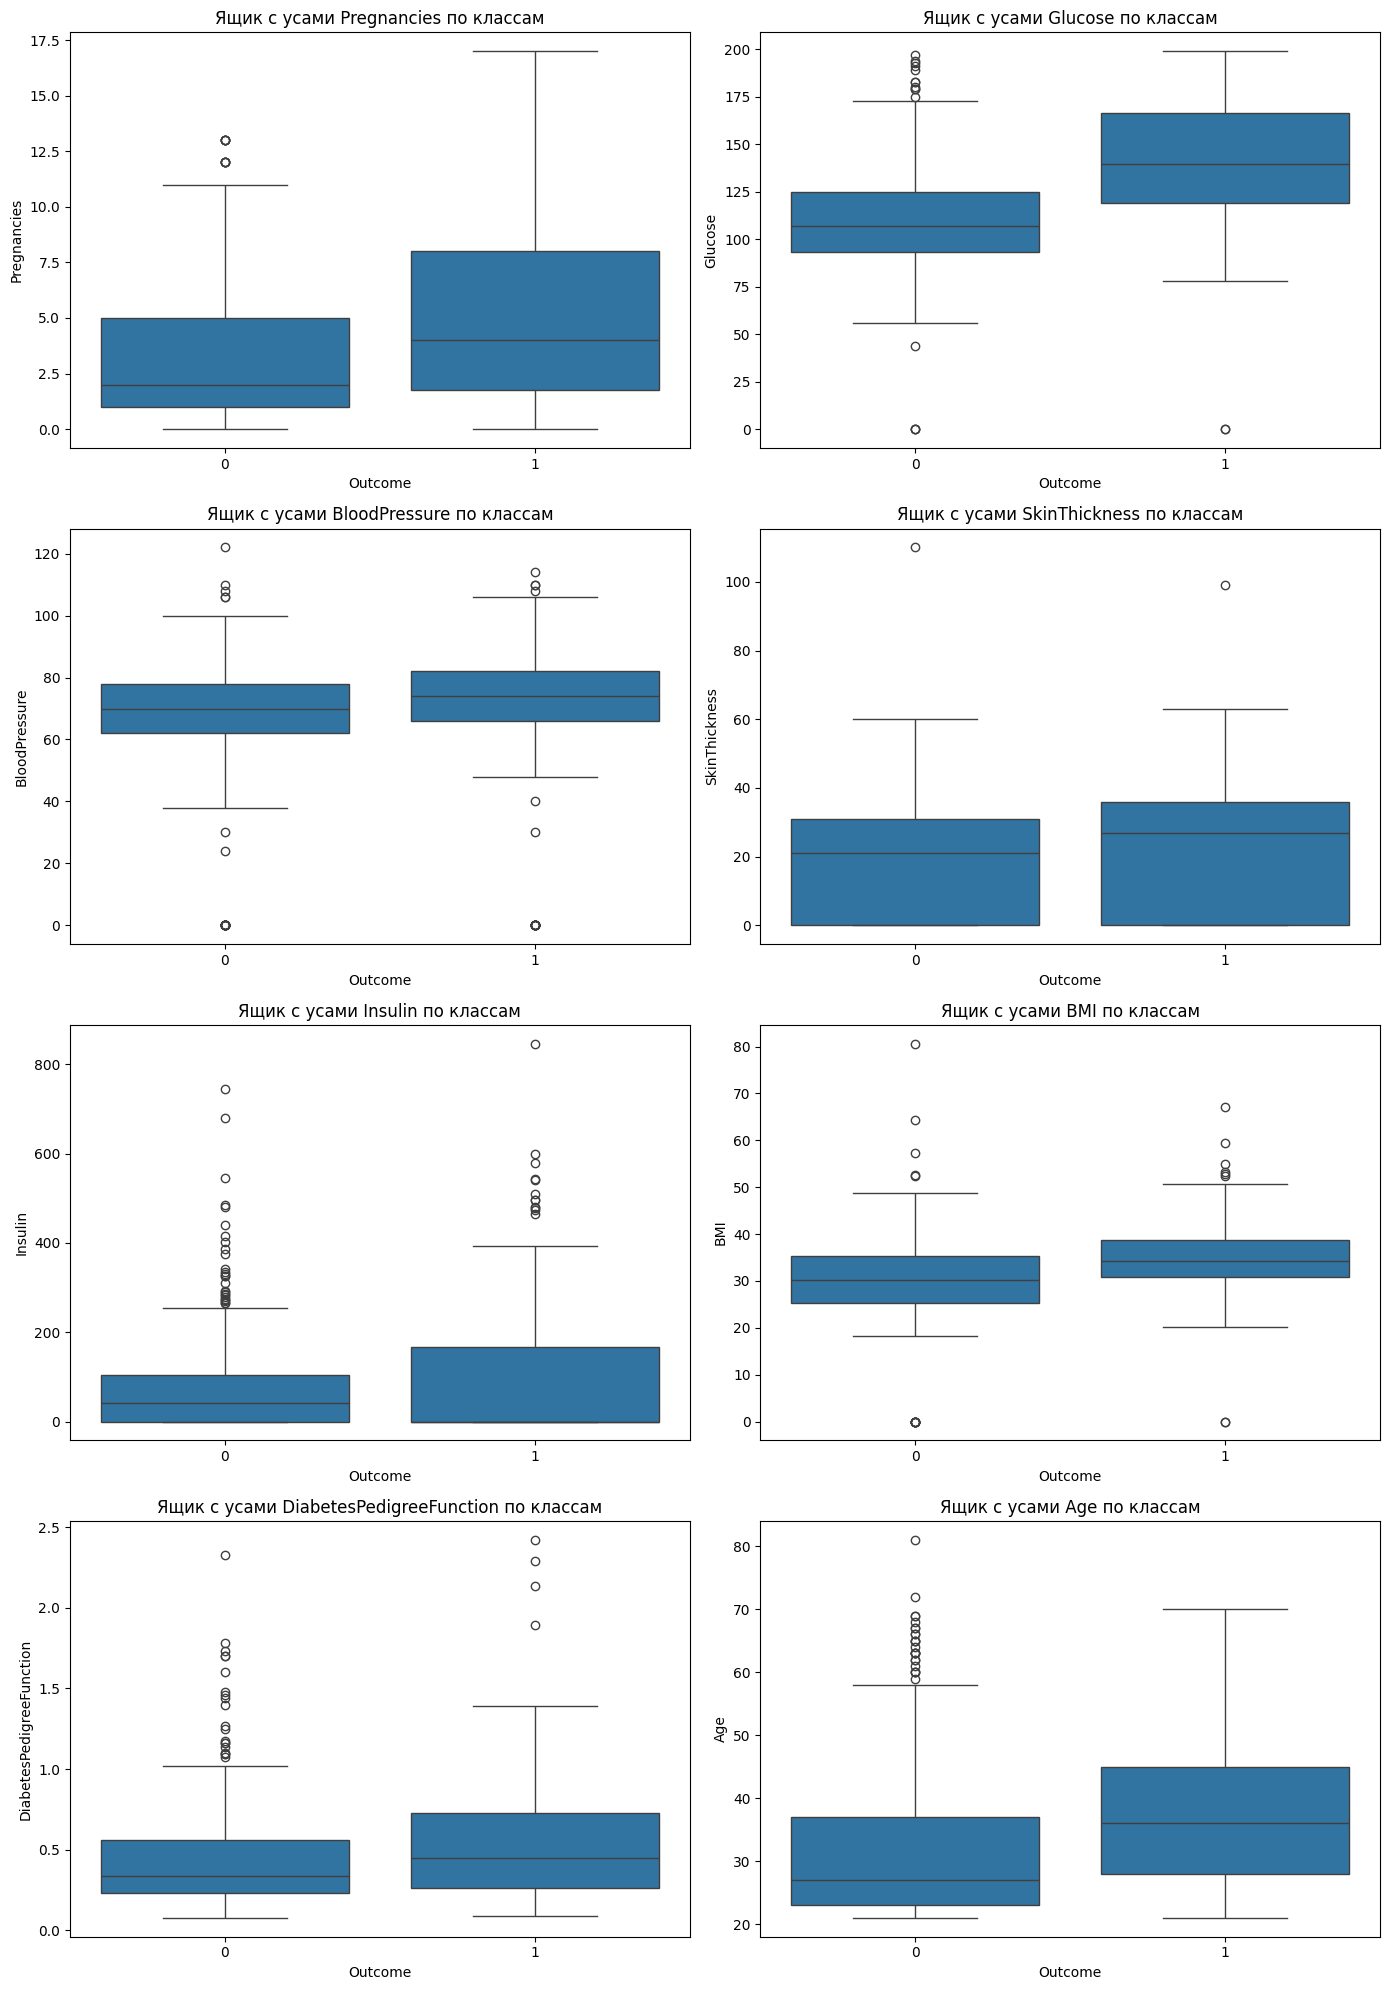

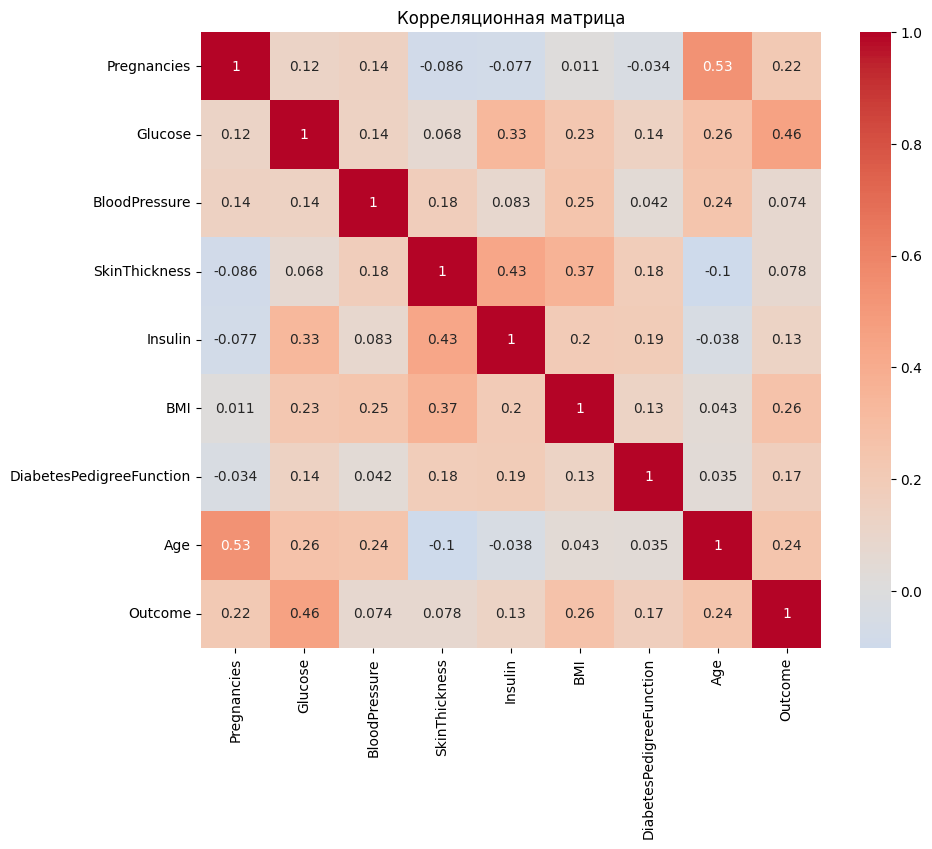


Описательные статистики по классам:
Outcome                     0           1
Pregnancies count  506.000000  272.000000
            mean     3.278656    4.830882
            std      3.008802    3.733868
            min      0.000000    0.000000
            25%      1.000000    1.750000
...                       ...         ...
Age         min     21.000000   21.000000
            25%     23.000000   28.000000
            50%     27.000000   36.000000
            75%     37.000000   45.000000
            max     81.000000   70.000000

[64 rows x 2 columns]

Дисперсия признаков:
DiabetesPedigreeFunction        0.109019
Pregnancies                    11.294937
BMI                            67.497511
Age                           138.981079
SkinThickness                 266.659567
BloodPressure                 379.146121
Glucose                      1023.413281
Insulin                     13251.118110
dtype: float64


In [51]:
print("Форма датасета:", df.shape)
print("\nТипы данных:")
print(df.dtypes)
print("\nПропуски:")
print(df.isnull().sum())
print("\nПервые строки:")
print(df.head())

# Проверка на нулевые/некорректные значения
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI']
print("\nНулевые значения в медицински значимых столбцах:")
for col in zero_cols:
    print(f"{col}: {(df[col] == 0).sum()}")

# Анализ целевой переменной
print("\nБаланс классов (Outcome):")
print(df['Outcome'].value_counts())
print(df['Outcome'].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Outcome')
plt.title('Распределение целевой переменной')
plt.show()

# Распределения числовых признаков по классам
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data=df, x=col, hue='Outcome', kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Распределение {col} по классам')
plt.tight_layout()
plt.show()

# Ящик с усами для выявления выбросов
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='Outcome', y=col, ax=axes[i])
    axes[i].set_title(f'Ящик с усами {col} по классам')
plt.tight_layout()
plt.show()

# Корреляционная матрица
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.show()

# Статистики по классам
print("\nОписательные статистики по классам:")
print(df.groupby('Outcome')[features].describe().T)

# Проверка на константные признаки
print("\nДисперсия признаков:")
print(df[features].var().sort_values())

In [52]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler


zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI']
for col in zero_as_missing:
    df[col] = df[col].replace(0, np.nan)

df = df.dropna(subset=['Glucose'])

imputer = KNNImputer(n_neighbors=5)
feature_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
df[feature_cols] = imputer.fit_transform(df[feature_cols])

# Удаление явных выбросов по медицинским критериям
# Диастолическое давление < 20 или > 130 — недостоверно
df = df[(df['BloodPressure'] >= 20) & (df['BloodPressure'] <= 130)]
# BMI < 12 или > 70 — физиологически маловероятно
df = df[(df['BMI'] >= 12) & (df['BMI'] <= 70)]
# SkinThickness > 99 — верхняя граница измерений в датасете
df = df[df['SkinThickness'] <= 99]
# Insulin > 800 — клинически экстремальное значение, вероятно ошибка
df = df[df['Insulin'] <= 800]

# Масштабирование признаков
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])
print(df['Age'])    

# Финальная проверка
print("Форма после предобработки:", df.shape)
print("Пропуски:", df.isnull().sum().sum())
print("Дубликаты:", df.duplicated().sum())

537    2.858507
596    1.074698
589   -0.709111
466   -0.963941
290   -1.048884
         ...   
691    0.904812
298    1.074698
455    0.395152
88     0.819868
159    1.159642
Name: Age, Length: 770, dtype: float64
Форма после предобработки: (770, 9)
Пропуски: 0
Дубликаты: 0


In [53]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Конструирование признаков
# BMI категории (по ВОЗ)
X['BMI_Category'] = pd.cut(X['BMI'],
                        bins=[-np.inf, 18.5, 25, 30, np.inf],
                        labels=[0, 1, 2, 3])  # 0: недостаток, 1: норма, 2: избыток, 3: ожирение

# Возрастные группы
X['Age_Group'] = pd.cut(X['Age'],
                        bins=[-np.inf, 30, 40, 50, np.inf],
                        labels=[0, 1, 2, 3])

# Глюкоза по медицинским порогам (норма < 140)
X['Glucose_High'] = (X['Glucose'] >= 140).astype(int)

# Комбинированные признаки
X['Glucose_BMI'] = X['Glucose'] * X['BMI']
X['Insulin_Glucose_Ratio'] = X['Insulin'] / (X['Glucose'] + 1e-6)  # избегаем деления на ноль

# Число беременностей с учётом возраста
X['Pregnancies_per_Age'] = X['Pregnancies'] / (X['Age'] + 1e-6)

# Преобразуем категориальные признаки в числовые
X['BMI_Category'] = X['BMI_Category'].astype(int)
X['Age_Group'] = X['Age_Group'].astype(int)


In [54]:
print(X)
print(y)

     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
537    -1.137714 -2.130702      -1.009909      -0.183454 -0.710693 -1.534723   
596    -1.137714 -1.801712       0.293008      -0.054214 -0.710693  1.809488   
589    -1.137714 -1.604318      -1.058769      -0.614253 -0.710693 -1.619745   
466    -1.137714 -1.571419      -1.661368      -2.078972 -0.389017 -0.670329   
290    -1.137714 -1.439823       1.270197      -0.032674 -0.353275  0.619176   
..           ...       ...            ...            ...       ...       ...   
691     2.721492  1.192098       3.387438       0.764306 -0.710693  1.384377   
298     3.018354 -0.716045       0.455873      -0.463473  0.933430  0.576665   
455     3.018354  1.751381      -0.847045       0.075026 -0.710693  0.151553   
88      3.315216  0.468320      -0.195586       0.290426  0.272206  0.647517   
159     3.908939  1.356593      -0.032721       1.259726  0.307948  1.185991   

     DiabetesPedigreeFunction       Age

Лучшие параметры: {'copy_X': True, 'fit_intercept': True, 'positive': True}
Лучший ROC-AUC на CV: 0.8358

Test Accuracy: 0.7403
Precision:     0.7714
Recall:        0.4576
F1-score:      0.5745
ROC-AUC:       0.8344


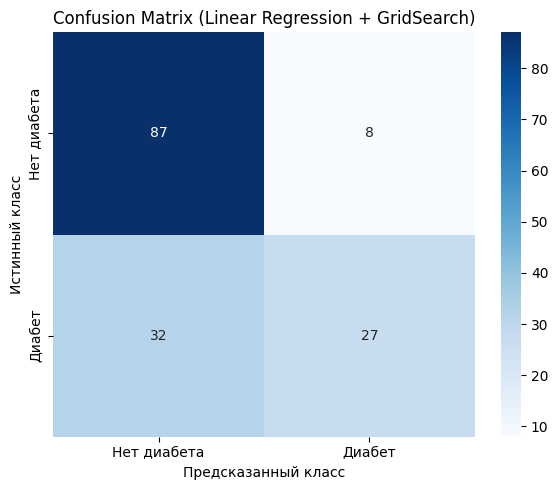

In [55]:
# Линейная регрессия
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Инициализация модели
lr_model = LinearRegression()

# 3. Сетка гиперпараметров (минимум 3, как требуется в задании)
param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False],
    'copy_X': [True, False]
}

# 4. Подбор гиперпараметров (5-кратная кросс-валидация)
grid_search = GridSearchCV(lr_model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший ROC-AUC на CV: {grid_search.best_score_:.4f}\n")

# 5. Предсказания лучшей модели
y_pred_continuous = grid_search.best_estimator_.predict(X_test)

# Преобразуем в бинарные предсказания с порогом 0.5
y_pred = (y_pred_continuous >= 0.5).astype(int)

# 6. Оценка метрик
print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision:     {precision_score(y_test, y_pred, zero_division=0):.4f}')
print(f'Recall:        {recall_score(y_test, y_pred, zero_division=0):.4f}')
print(f'F1-score:      {f1_score(y_test, y_pred, zero_division=0):.4f}')

# Для ROC-AUC используем непрерывные предсказания
roc_auc = roc_auc_score(y_test, y_pred_continuous)
print(f'ROC-AUC:       {roc_auc:.4f}')

# 7. Визуализация матрицы ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Нет диабета', 'Диабет'],
            yticklabels=['Нет диабета', 'Диабет'])
plt.title('Confusion Matrix (Linear Regression + GridSearch)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

✅ Лучшие параметры: {'C': 0.1, 'fit_intercept': True, 'solver': 'liblinear'}
📈 Лучший ROC-AUC на CV: 0.8315

Test Accuracy: 0.7468
Precision:     0.7500
Recall:        0.5085
F1-score:      0.6061
ROC-AUC:       0.8455


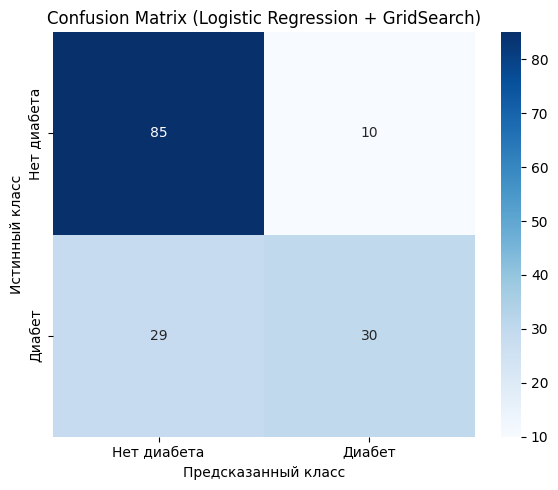

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Разделение данных (если ещё не разделяли для sklearn)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Инициализация модели
# max_iter=1000 гарантирует сходимость оптимизатора
log_reg = LogisticRegression(max_iter=1000)

# 3. Сетка гиперпараметров (минимум 3, как требуется в задании)
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'solver': ['lbfgs', 'liblinear'],
    'fit_intercept': [True, False]
}

# 4. Подбор гиперпараметров (5-кратная кросс-валидация)
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"✅ Лучшие параметры: {grid_search.best_params_}")
print(f"📈 Лучший ROC-AUC на CV: {grid_search.best_score_:.4f}\n")

# 5. Предсказания лучшей модели
y_pred = grid_search.best_estimator_.predict(X_test)               # Твёрдые классы (0 или 1)
y_prob = grid_search.best_estimator_.predict_proba(X_test)[:, 1]   # Вероятности класса 1 (нужны для ROC-AUC)

# 6. Оценка метрик
print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision:     {precision_score(y_test, y_pred, zero_division=0):.4f}')
print(f'Recall:        {recall_score(y_test, y_pred, zero_division=0):.4f}')
print(f'F1-score:      {f1_score(y_test, y_pred, zero_division=0):.4f}')
print(f'ROC-AUC:       {roc_auc_score(y_test, y_prob):.4f}')

# 7. Визуализация матрицы ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Нет диабета', 'Диабет'],
            yticklabels=['Нет диабета', 'Диабет'])
plt.title('Confusion Matrix (Logistic Regression + GridSearch)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

✅ Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
📈 Лучший ROC-AUC на CV: 0.7767

Test Accuracy: 0.7273
Precision:     0.7073
Recall:        0.4915
F1-score:      0.5800
ROC-AUC:       0.8293


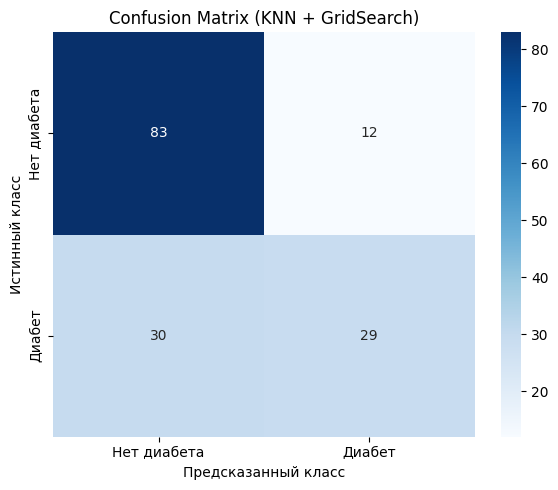

In [57]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Инициализация модели
knn_model = KNeighborsClassifier()

# 3. Сетка гиперпараметров (минимум 3, как требуется в задании)
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 4. Подбор гиперпараметров (5-кратная кросс-валидация)
grid_search = GridSearchCV(knn_model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"✅ Лучшие параметры: {grid_search.best_params_}")
print(f"📈 Лучший ROC-AUC на CV: {grid_search.best_score_:.4f}\n")

# 5. Предсказания лучшей модели
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)
y_prob = best_knn.predict_proba(X_test)[:, 1]

# 6. Оценка метрик
print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision:     {precision_score(y_test, y_pred, zero_division=0):.4f}')
print(f'Recall:        {recall_score(y_test, y_pred, zero_division=0):.4f}')
print(f'F1-score:      {f1_score(y_test, y_pred, zero_division=0):.4f}')
print(f'ROC-AUC:       {roc_auc_score(y_test, y_prob):.4f}')

# 7. Визуализация матрицы ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Нет диабета', 'Диабет'],
            yticklabels=['Нет диабета', 'Диабет'])
plt.title('Confusion Matrix (KNN + GridSearch)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

✅ Лучшие параметры: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
📈 Лучший ROC-AUC на CV: 0.8277

Test Accuracy: 0.7403
Precision:     0.7714
Recall:        0.4576
F1-score:      0.5745
ROC-AUC:       0.8389


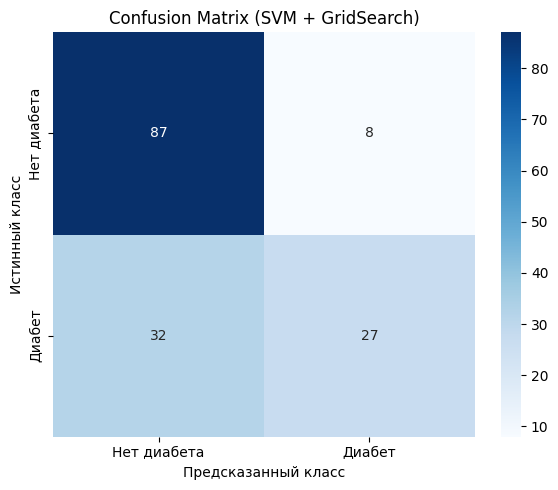

In [58]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Инициализация модели (базовая, параметры будут перебираться в GridSearch)
# probability=True необходим для расчета вероятностей (нужно для ROC-AUC)
svm_model = SVC(probability=True, random_state=42)

# 3. Сетка гиперпараметров (минимум 3, как требуется в задании)
param_grid = {
    'C': [0.1, 1.0, 10.0],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto', 0.1]
}

# 4. Подбор гиперпараметров (5-кратная кросс-валидация)
grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"✅ Лучшие параметры: {grid_search.best_params_}")
print(f"📈 Лучший ROC-AUC на CV: {grid_search.best_score_:.4f}\n")

# 5. Предсказания лучшей модели
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test)
y_prob = best_svm.predict_proba(X_test)[:, 1]

# 6. Оценка метрик
print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision:     {precision_score(y_test, y_pred, zero_division=0):.4f}')
print(f'Recall:        {recall_score(y_test, y_pred, zero_division=0):.4f}')
print(f'F1-score:      {f1_score(y_test, y_pred, zero_division=0):.4f}')
print(f'ROC-AUC:       {roc_auc_score(y_test, y_prob):.4f}')

# 7. Визуализация матрицы ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Нет диабета', 'Диабет'],
            yticklabels=['Нет диабета', 'Диабет'])
plt.title('Confusion Matrix (SVM + GridSearch)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

=== Decision Tree (без ограничения глубины) ===
Test Accuracy: 0.6948
Precision:     0.5968
Recall:        0.6271
F1-score:      0.6116
ROC-AUC:       0.6820

=== Decision Tree (max_depth=3) ===
Test Accuracy: 0.7338
Precision:     0.6957
Recall:        0.5424
F1-score:      0.6095
ROC-AUC:       0.8028



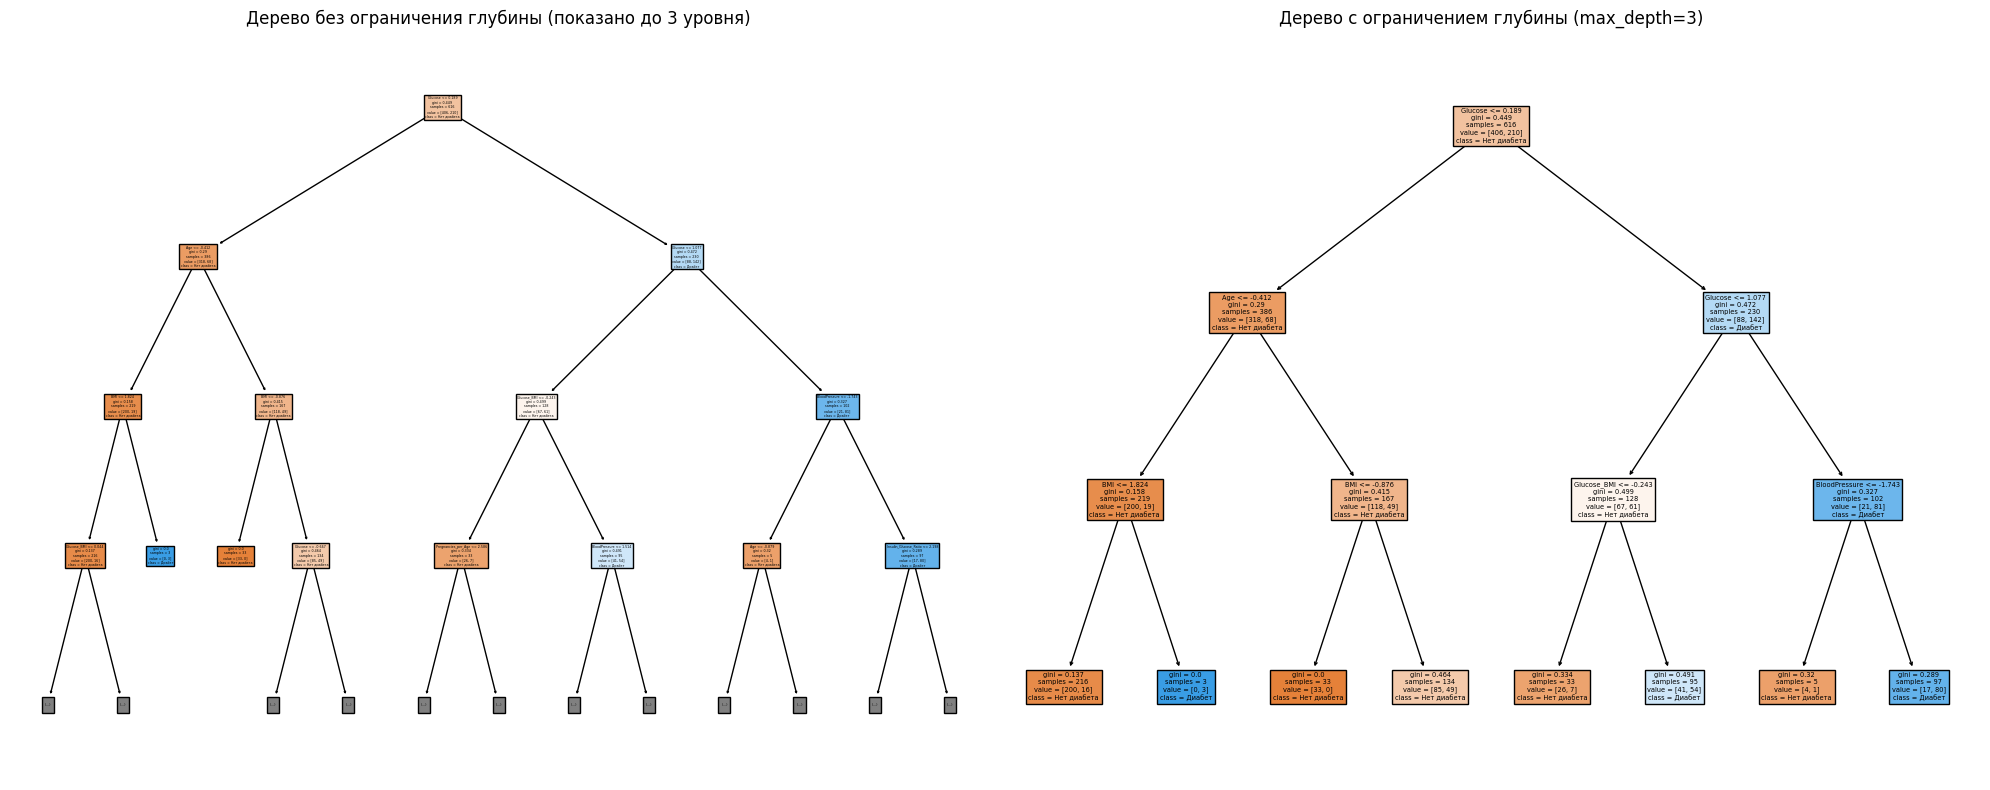

=== Анализ переобучения (Bias-Variance Tradeoff) ===
Accuracy Train (без ограничения): 1.0000
Accuracy Test  (без ограничения): 0.6948
📉 Разница (Train - Test): 0.3052

Accuracy Train (max_depth=3): 0.7873
Accuracy Test  (max_depth=3): 0.7338
📈 Разница (Train - Test): 0.0536


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Убедитесь, что данные уже разделены (как в вашем ноутбуке):
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Обучаем дерево БЕЗ ограничения глубины
dt_unlimited = DecisionTreeClassifier(random_state=42)
dt_unlimited.fit(X_train, y_train)
y_pred_unlim = dt_unlimited.predict(X_test)
y_prob_unlim = dt_unlimited.predict_proba(X_test)[:, 1]

print("=== Decision Tree (без ограничения глубины) ===")
print(f'Test Accuracy: {accuracy_score(y_test, y_pred_unlim):.4f}')
print(f'Precision:     {precision_score(y_test, y_pred_unlim, zero_division=0):.4f}')
print(f'Recall:        {recall_score(y_test, y_pred_unlim, zero_division=0):.4f}')
print(f'F1-score:      {f1_score(y_test, y_pred_unlim, zero_division=0):.4f}')
print(f'ROC-AUC:       {roc_auc_score(y_test, y_prob_unlim):.4f}\n')

# 2. Обучаем дерево С ограничением глубины (max_depth=3)
dt_limited = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_limited.fit(X_train, y_train)
y_pred_lim = dt_limited.predict(X_test) 
y_prob_lim = dt_limited.predict_proba(X_test)[:, 1]

print("=== Decision Tree (max_depth=3) ===")
print(f'Test Accuracy: {accuracy_score(y_test, y_pred_lim):.4f}')
print(f'Precision:     {precision_score(y_test, y_pred_lim, zero_division=0):.4f}')
print(f'Recall:        {recall_score(y_test, y_pred_lim, zero_division=0):.4f}')
print(f'F1-score:      {f1_score(y_test, y_pred_lim, zero_division=0):.4f}')
print(f'ROC-AUC:       {roc_auc_score(y_test, y_prob_lim):.4f}\n')

# 3. Визуализация структур деревьев
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

plot_tree(dt_unlimited,
          feature_names=X.columns,
          class_names=['Нет диабета', 'Диабет'],
          filled=True,
          max_depth=3, # Ограничиваем глубину отрисовки для читаемости
          ax=axes[0])
axes[0].set_title('Дерево без ограничения глубины (показано до 3 уровня)')

plot_tree(dt_limited,
          feature_names=X.columns,
          class_names=['Нет диабета', 'Диабет'],
          filled=True,
          ax=axes[1])
axes[1].set_title('Дерево с ограничением глубины (max_depth=3)')

plt.tight_layout()
plt.show()

# 4. Сравнение метрик на Train и Test для анализа переобучения
print("=== Анализ переобучения (Bias-Variance Tradeoff) ===")
print(f"Accuracy Train (без ограничения): {accuracy_score(y_train, dt_unlimited.predict(X_train)):.4f}")
print(f"Accuracy Test  (без ограничения): {accuracy_score(y_test, y_pred_unlim):.4f}")
print(f"📉 Разница (Train - Test): {accuracy_score(y_train, dt_unlimited.predict(X_train)) - accuracy_score(y_test, y_pred_unlim):.4f}")

print(f"\nAccuracy Train (max_depth=3): {accuracy_score(y_train, dt_limited.predict(X_train)):.4f}")
print(f"Accuracy Test  (max_depth=3): {accuracy_score(y_test, y_pred_lim):.4f}")
print(f"📈 Разница (Train - Test): {accuracy_score(y_train, dt_limited.predict(X_train)) - accuracy_score(y_test, y_pred_lim):.4f}")

Fitting 5 folds for each of 75 candidates, totalling 375 fits
Лучшие гиперпараметры: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100, 'random_state': 42}
Test Accuracy: 0.7662
Precision: 0.7949
Recall: 0.5254
F1-score: 0.6327
ROC-AUC: 0.8494


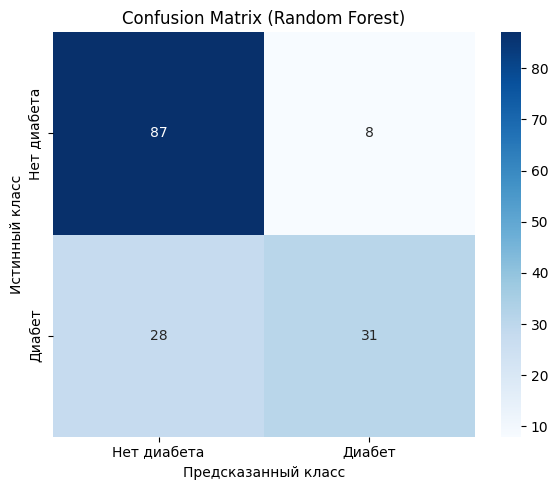

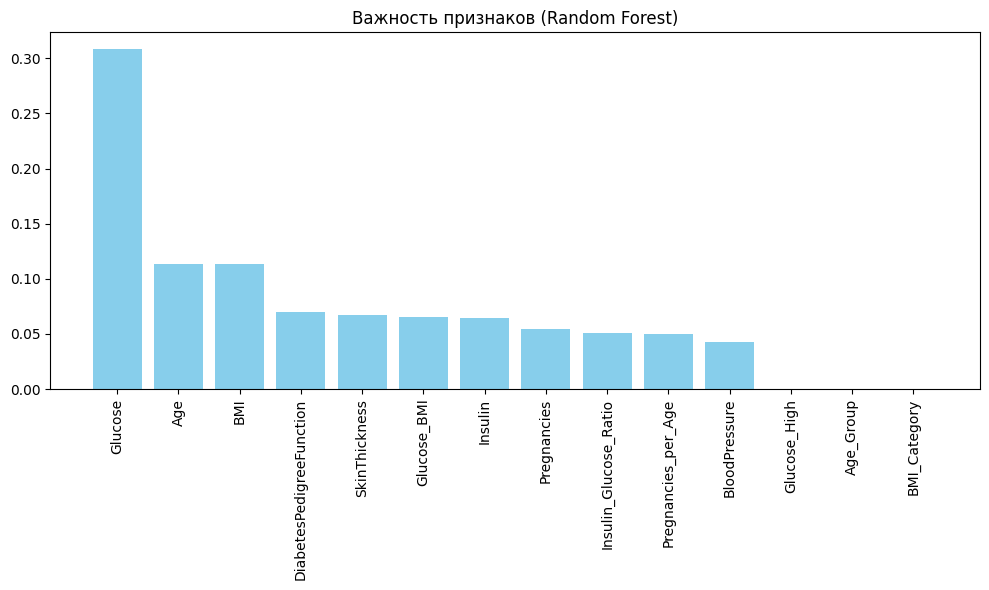

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Определение сетки гиперпараметров для настройки
param_grid = {
    'n_estimators': [50, 100, 150, 200, 300],  # Количество деревьев
    'max_depth': [None, 5, 10, 15, 20],         # Глубина деревьев (None = без ограничений)
    'min_samples_split': [2, 5, 10],            # Мин. число объектов для разбиения
    'random_state': [42]
}

# 2. Инициализация модели и GridSearchCV
rf_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf_model, 
                           param_grid=param_grid, 
                           cv=5, 
                           scoring='roc_auc', 
                           n_jobs=-1, 
                           verbose=1)

# 3. Обучение с кросс-валидацией
grid_search.fit(X_train, y_train)

# 4. Вывод лучших гиперпараметров и метрик на тесте
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("Лучшие гиперпараметры:", grid_search.best_params_)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# 5. Визуализация матрицы ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Нет диабета', 'Диабет'],
            yticklabels=['Нет диабета', 'Диабет'])
plt.title('Confusion Matrix (Random Forest)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

# 6. Важность признаков (полезно для интерпретации)
importances = best_rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title('Важность признаков (Random Forest)')
plt.bar(range(len(importances)), importances[indices], align="center", color='skyblue')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

Оптимизация: GradientBoosting
Best ROC-AUC: 0.8483 | Параметры: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}

Оптимизация: XGBoost
Best ROC-AUC: 0.8546 | Параметры: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}

Оптимизация: LightGBM
Best ROC-AUC: 0.8633 | Параметры: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

Оптимизация: CatBoost
Best ROC-AUC: 0.8605 | Параметры: {'depth': 3, 'iterations': 100, 'learning_rate': 0.05}

Итоговые метрики на тестовой выборке:
                  Accuracy  Precision  Recall  F1-score  ROC-AUC
GradientBoosting    0.7338     0.6957  0.5424    0.6095   0.8483
XGBoost             0.7532     0.7561  0.5254    0.6200   0.8546
LightGBM            0.7403     0.7209  0.5254    0.6078   0.8633
CatBoost            0.7468     0.7941  0.4576    0.5806   0.8605

ДЕТАЛЬНАЯ ОЦЕНКА ФИНАЛЬНОЙ МОДЕЛИ: LightGBM
Лучшие параметры LightGBM: {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'sp

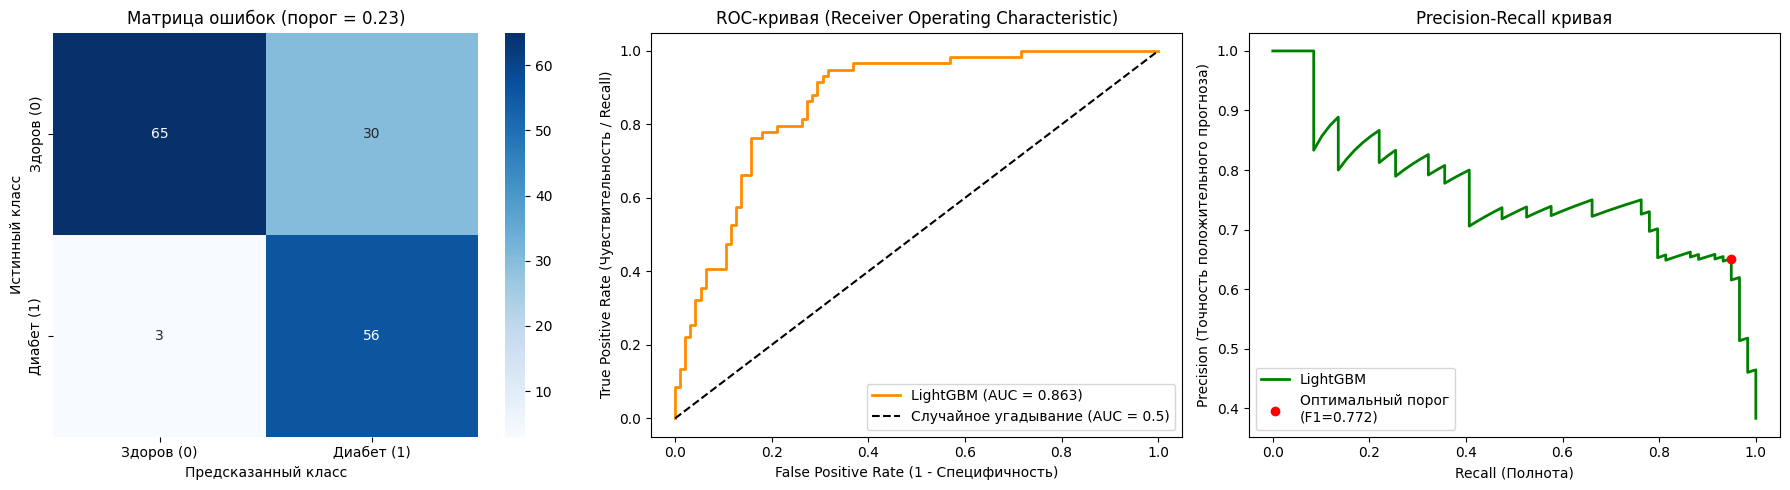


Генерация SHAP-графика важности признаков...


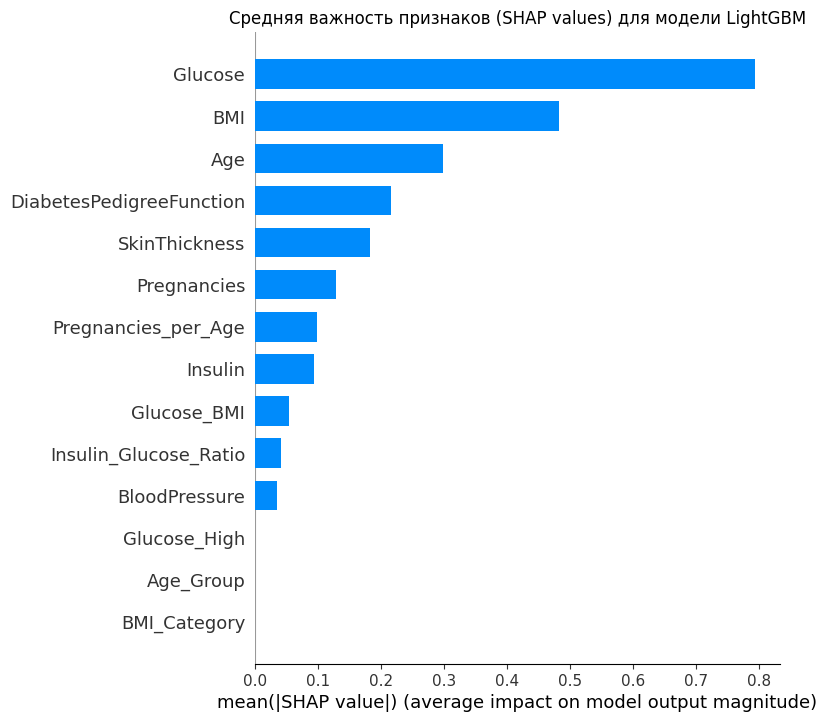

In [61]:
import numpy as np
from pathlib import Path

from pathlib import Path

import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, 
                             precision_recall_curve, confusion_matrix)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

# Убедитесь, что X_train, X_test, y_train, y_test уже определены из ячейки 5
# Если нет, раскомментируйте строки ниже:
# X = df.drop('Outcome', axis=1)
# y = df['Outcome']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Настройка библиотек
xgb = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
lgbm = LGBMClassifier(random_state=42, verbose=-1)
catboost = CatBoostClassifier(random_state=42, verbose=0)  # cat_features=[], т.к. данные уже закодированы
gb = GradientBoostingClassifier(random_state=42)

# Сетки гиперпараметров (можно расширить, но 3x3 достаточно для быстрой и надежной настройки)
param_grids = {
    'GradientBoosting': {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 4, 5]
    },
    'XGBoost': {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 4, 5]
    },
    'LightGBM': {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 4, 5]
    },
    'CatBoost': {
        'iterations': [50, 100, 150],
        'learning_rate': [0.01, 0.05, 0.1],
        'depth': [3, 4, 5]
    }
}

models = {'GradientBoosting': gb, 'XGBoost': xgb, 'LightGBM': lgbm, 'CatBoost': catboost}
best_models = {}
test_metrics = {}

for name, model in models.items():
    print(f"Оптимизация: {name}")
    grid = GridSearchCV(estimator=model, param_grid=param_grids[name], 
                        cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    
    y_pred = best_models[name].predict(X_test)
    y_prob = best_models[name].predict_proba(X_test)[:, 1]
    
    test_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }
    print(f"Best ROC-AUC: {test_metrics[name]['ROC-AUC']:.4f} | Параметры: {grid.best_params_}\n")

# Вывод итоговой таблицы
results_df = pd.DataFrame(test_metrics).T.round(4)
print("Итоговые метрики на тестовой выборке:")
print(results_df)

print("\n" + "="*60)
print("ДЕТАЛЬНАЯ ОЦЕНКА ФИНАЛЬНОЙ МОДЕЛИ: LightGBM")
print("="*60)

final_model = best_models['LightGBM']
print(f"Лучшие параметры LightGBM: {final_model.get_params()}")

# Получаем вероятности для тестовой выборки
y_prob = final_model.predict_proba(X_test)[:, 1]

# --- Анализ оптимального порога классификации (Закрывает замечание №5) ---
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)

# Рассчитываем F1-score для каждого порога (игнорируем деление на ноль)
with np.errstate(divide='ignore', invalid='ignore'):
    f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals)
f1_scores = np.nan_to_num(f1_scores) # Заменяем NaN на 0

# Находим порог, который максимизирует F1-score
# (В медицине иногда максимизируют Recall при допустимом Precision, но F1 - универсальный компромисс)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print(f"\nАнализ порога классификации:")
print(f"  - Стандартный эвристический порог: 0.5000")
print(f"  - Оптимальный порог (максимизирующий F1): {optimal_threshold:.4f}")

# Пересчитываем предсказания и метрики с оптимальным порогом
y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

final_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_optimal),
    'Precision': precision_score(y_test, y_pred_optimal),
    'Recall': recall_score(y_test, y_pred_optimal),
    'F1-score': f1_score(y_test, y_pred_optimal),
    'ROC-AUC': roc_auc_score(y_test, y_prob) # AUC не зависит от порога
}

print("\nИтоговые метрики LightGBM с оптимальным порогом:")
for metric, value in final_metrics.items():
    print(f"  {metric:12s}: {value:.4f}")


# --- 3. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ (Матрица ошибок, ROC, PR) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3.1. Матрица ошибок
cm = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Здоров (0)', 'Диабет (1)'], 
            yticklabels=['Здоров (0)', 'Диабет (1)'])
axes[0].set_title(f'Матрица ошибок (порог = {optimal_threshold:.2f})')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

# 3.2. ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'LightGBM (AUC = {final_metrics["ROC-AUC"]:.3f})', color='darkorange', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Случайное угадывание (AUC = 0.5)')
axes[1].set_title('ROC-кривая (Receiver Operating Characteristic)')
axes[1].set_xlabel('False Positive Rate (1 - Специфичность)')
axes[1].set_ylabel('True Positive Rate (Чувствительность / Recall)')
axes[1].legend(loc='lower right')

# 3.3. Precision-Recall кривая
axes[2].plot(recall_vals, precision_vals, label=f'LightGBM', color='green', linewidth=2)
# Отмечаем точку оптимального порога на графике
opt_recall = recall_vals[best_idx]
opt_precision = precision_vals[best_idx]
axes[2].scatter([opt_recall], [opt_precision], color='red', zorder=5, 
                label=f'Оптимальный порог\n(F1={f1_scores[best_idx]:.3f})')
axes[2].set_title('Precision-Recall кривая')
axes[2].set_xlabel('Recall (Полнота)')
axes[2].set_ylabel('Precision (Точность положительного прогноза)')
axes[2].legend(loc='lower left')

plt.tight_layout()
plt.show()

# --- 4. ИНТЕРПРЕТИРУЕМОСТЬ (SHAP) - Опционально, но очень рекомендуется для курсовой ---
try:
    import shap
    print("\nГенерация SHAP-графика важности признаков...")
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_test)
    
    # Для бинарной классификации LightGBM shap_values часто возвращается как список [класс_0, класс_1]
    if isinstance(shap_values, list):
        shap_values = shap_values[1] # Берем вклад в класс "Диабет" (1)
        
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
    plt.title("Средняя важность признаков (SHAP values) для модели LightGBM")
    plt.show()
except ImportError:
    print("\nБиблиотека shap не установлена. Пропускаем визуализацию интерпретируемости.")


In [62]:
import joblib
from pathlib import Path

from pathlib import Path

import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier

best_model = LGBMClassifier(
    learning_rate=0.05,
    max_depth=3,
    n_estimators=100,
    random_state=42,
    verbose=-1
)

class ZeroToNanTransformer:
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI']
        for col in zero_cols:
            if col in X.columns:
                X[col] = X[col].replace(0, np.nan)
        return X

class NotebookFeatureEngineer:
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X['BMI_Category'] = pd.cut(X['BMI'], bins=[-np.inf, 18.5, 25, 30, np.inf], labels=[0, 1, 2, 3]).astype(int)
        X['Age_Group'] = pd.cut(X['Age'], bins=[-np.inf, 30, 40, 50, np.inf], labels=[0, 1, 2, 3]).astype(int)
        X['Glucose_High'] = (X['Glucose'] >= 140).astype(int)
        X['Glucose_BMI'] = X['Glucose'] * X['BMI']
        X['Insulin_Glucose_Ratio'] = X['Insulin'] / (X['Glucose'] + 1e-6)
        X['Pregnancies_per_Age'] = X['Pregnancies'] / (X['Age'] + 1e-6)
        return X

pipeline = Pipeline(steps=[
    ('zero_to_nan', ZeroToNanTransformer()),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('feature_engineer', NotebookFeatureEngineer()),
    ('scaler', StandardScaler()),
    ('model', best_model)
])

model_path = MODELS_DIR / 'diabetes_best_model_pipeline.pkl'
joblib.dump(pipeline, model_path)

print(f"✅ Пайплайн и лучшая модель (LightGBM) успешно сохранены в файл: {filename}")

✅ Пайплайн и лучшая модель (LightGBM) успешно сохранены в файл: diabetes_best_model_pipeline.pkl


In [63]:
import joblib
from pathlib import Path

from pathlib import Path

import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'data' / 'raw').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'diabetes.csv'
MODELS_DIR = PROJECT_ROOT / 'models'

PROJECT_ROOT = Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'diabetes.csv'
MODELS_DIR = PROJECT_ROOT / 'models'

# 1. Загрузка сохранённого объекта (Pipeline или модель)
pipeline = joblib.load(model_path)

# 2. Загрузка тестовых данных (должны содержать те же столбцы, что и при обучении)
test_df = pd.read_csv(PROCESSED_DATA_PATH)
X_test = test_df.drop('Outcome', axis=1)
y_test = test_df['Outcome']

# 3. Предсказание (Pipeline автоматически применит все преобразования)
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

# 4. Расчёт метрик
metrics = {
    'Accuracy (Точность)': accuracy_score(y_test, y_pred),
    'Recall (Полнота)': recall_score(y_test, y_pred),
    'Precision (Точность поз.)': precision_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
}

print("--- Метрики качества модели (из .pkl) ---")
for name, val in metrics.items():
    print(f"{name}: {val:.4f}")

# 5. Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Здоров (0)', 'Диабет (1)'],
            yticklabels=['Здоров (0)', 'Диабет (1)'])
plt.title('Матрица ошибок на тестовой выборке')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

NotFittedError: This KNNImputer instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
757    -1.137714  0.040632      -0.032721      -0.204994 -0.710693  0.534154   
285     0.940320  0.468320       0.130144      -0.355773  0.495593 -0.925396   
64      0.940320 -0.255459      -0.521315       0.462746 -0.710693  0.038190   
512     1.534044 -1.012136      -0.358450      -0.032674 -0.710693 -1.180463   
72      2.721492  0.139329       1.433061       0.742766 -0.710693  1.540251   
..           ...       ...            ...            ...       ...       ...   
177    -1.137714  0.238026       3.061709       1.798225  0.450915  4.898633   
237    -1.137714  1.882977       1.433061      -0.248074 -0.710693  1.639444   
729    -0.543990 -0.979237      -1.661368      -1.109673 -0.710693 -0.344410   
629     0.049734 -0.913439      -0.602748      -0.786573 -0.710693 -1.109611   
300    -1.137714  1.488189      -0.032721       0.419666 -0.710693 -0.032662   

     DiabetesPedigreeFunction       Age

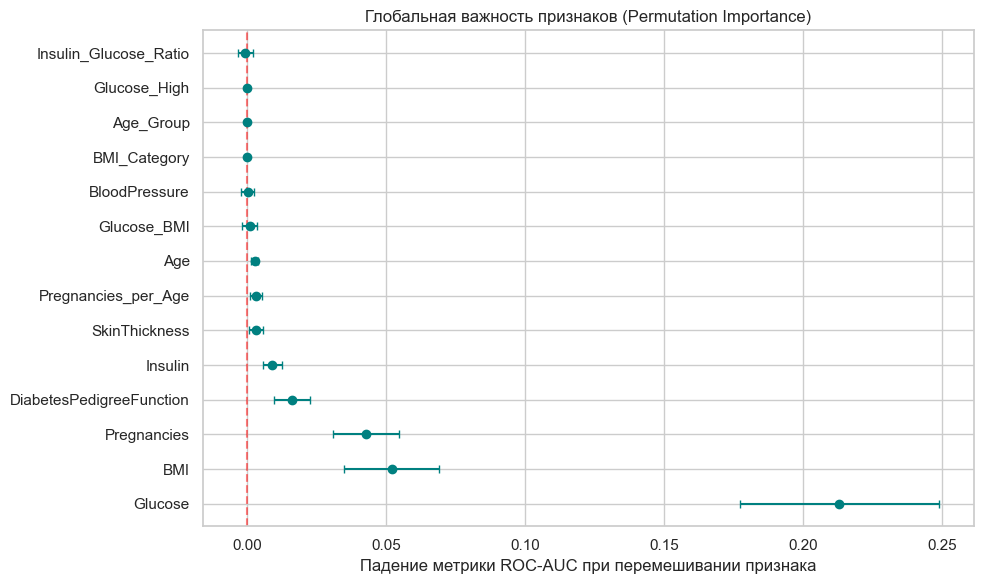

🔍 Вычисление SHAP-значений...


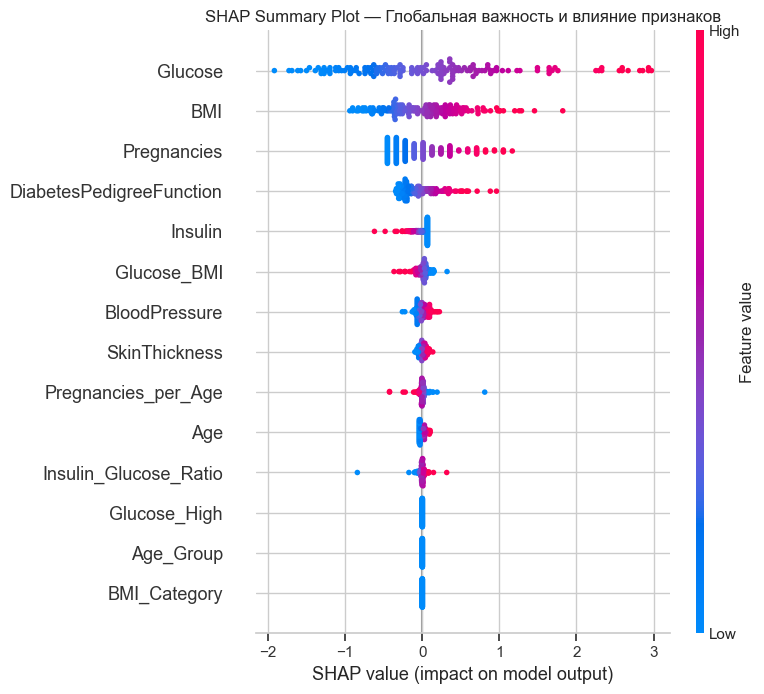

Локальное объяснение для пациента #10:
Истинный класс: 1, Предсказание модели: 0.148



🔍 Вычисление LIME...


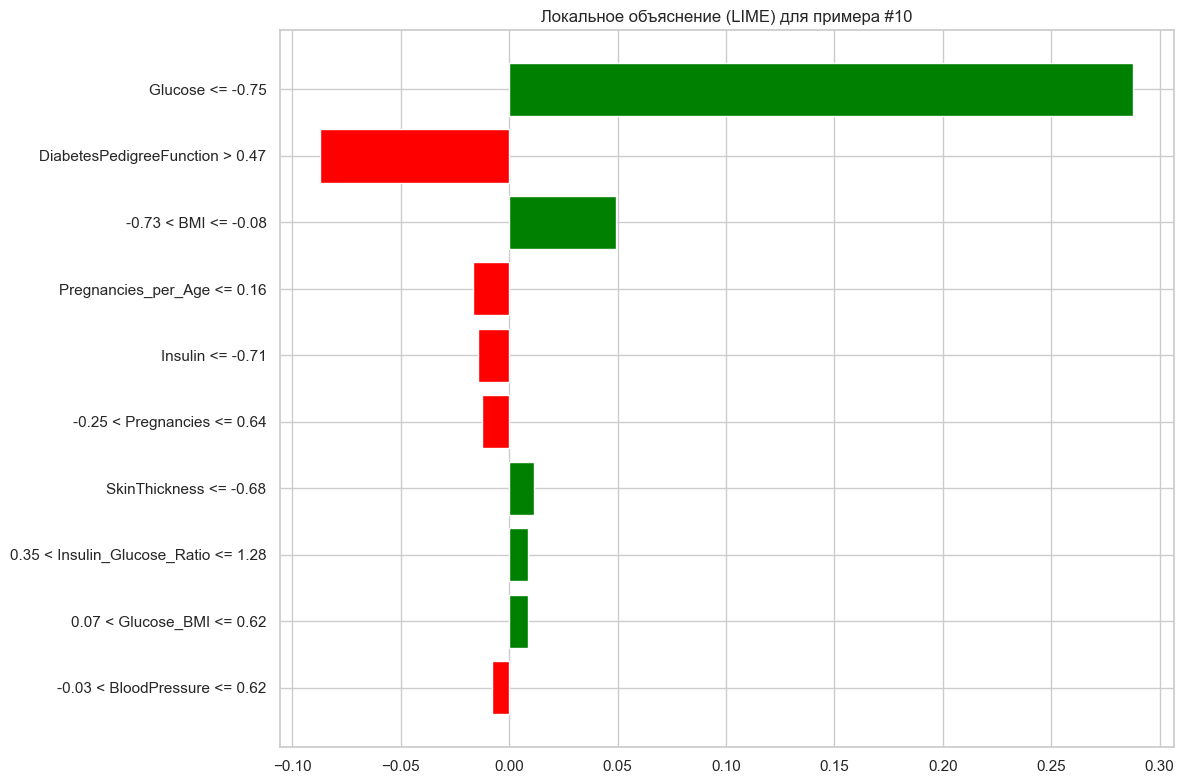

In [ ]:
import numpy as np
from pathlib import Path

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'data' / 'raw').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'diabetes.csv'
MODELS_DIR = PROJECT_ROOT / 'models'

PROJECT_ROOT = Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'diabetes.csv'
MODELS_DIR = PROJECT_ROOT / 'models'
import shap
import lime
import lime.lime_tabular
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, roc_auc_score

# Настройка визуализации
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
sns.set_theme(style="whitegrid")

# 1. Обучаем модель (ИСПРАВЛЕНИЕ ОШИБКИ NotFittedError)
# Используем Logistic Regression для линейной интерпретации
log_reg = LogisticRegression(random_state=42, max_iter=1000)
print(X_train)
log_reg.fit(X_train, y_train)

# Проверка качества
print(f"Модель обучена. ROC-AUC на тесте: {roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1]):.4f}\n")


print("📊 Вычисление Permutation Importance...")
perm_result = permutation_importance(
    log_reg, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='roc_auc'
)

perm_importance = pd.DataFrame({
    'feature': X.columns.tolist(),
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

plt.figure(figsize=(10, 6))
plt.errorbar(
    perm_importance['importance_mean'],
    perm_importance['feature'],
    xerr=perm_importance['importance_std'],
    fmt='o', capsize=3, color='teal'
)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Падение метрики ROC-AUC при перемешивании признака')
plt.title('Глобальная важность признаков (Permutation Importance)')
plt.tight_layout()
plt.show()

# ==========================================================
# 3. SHAP (Глобальная и Локальная интерпретация)
# ==========================================================
print("🔍 Вычисление SHAP-значений...")

explainer = shap.LinearExplainer(log_reg, X_train, feature_names=X.columns.tolist())
shap_values = explainer.shap_values(X_test)


plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist(), show=False)
plt.title('SHAP Summary Plot — Глобальная важность и влияние признаков')
plt.tight_layout()
plt.show()



# ==========================================================
# 4. LIME (Локальная интерпретация)
# ==========================================================
print("🔍 Вычисление LIME...")
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=X.columns.tolist(),
    class_names=['Нет диабета', 'Диабет'],
    mode='classification',
    random_state=42
)

exp = lime_explainer.explain_instance(
    X_sample.values.reshape(-1),
    log_reg.predict_proba,
    num_features=10,
    top_labels=1
)

fig = exp.as_pyplot_figure(label=exp.available_labels()[0]) # label=1 означает класс "Диабет"
plt.title(f'Локальное объяснение (LIME) для примера #{sample_idx}')
plt.tight_layout()
plt.show()